In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

INPUT_DIR = Path('/cta/users/guneyn23/relative_repair/window_mean_relative_all_regions')
OUTPUT_DIR = Path('/cta/users/guneyn23/relative_repair/window_mean_relative_real_minus_sim')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary = pd.read_csv(
    INPUT_DIR / 'window_mean_relative_results.tsv',
    sep='\t',
    dtype={'damage': str},
)

# Subtract mean simulated relative repair from mean real relative repair for each window.
summary['relative_real_minus_sim'] = (
    summary['relative_real'] - summary['relative_sim']
)

# Save the difference table in a directory separate from the ratio results.
summary.to_csv(
    OUTPUT_DIR / 'window_mean_relative_real_minus_sim.tsv',
    sep='\t',
    index=False,
)

summary[[
    'region', 'damage', 'time', 'window',
    'relative_real', 'relative_sim', 'relative_real_minus_sim'
]].head()

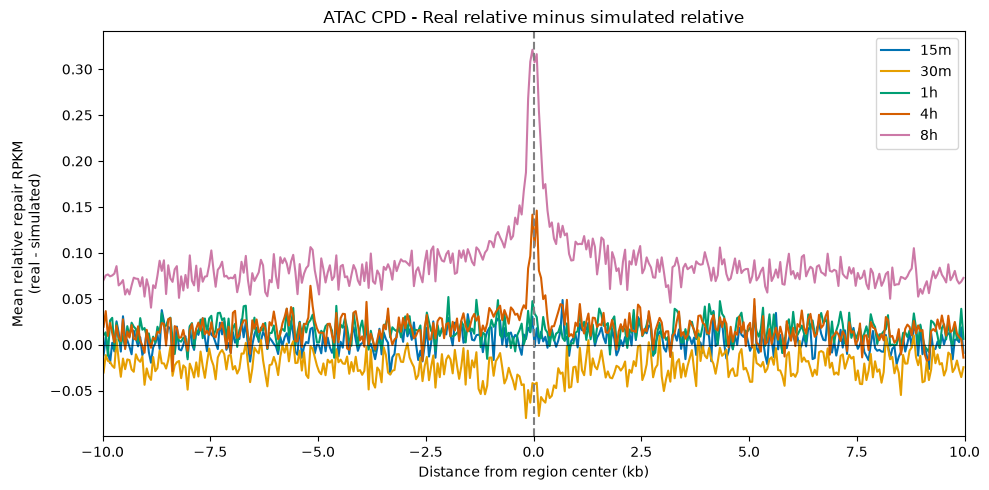

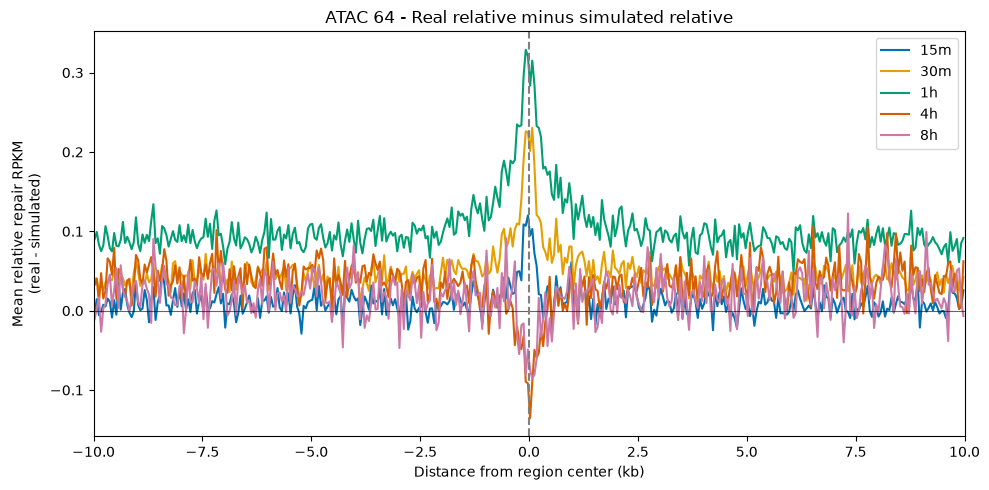

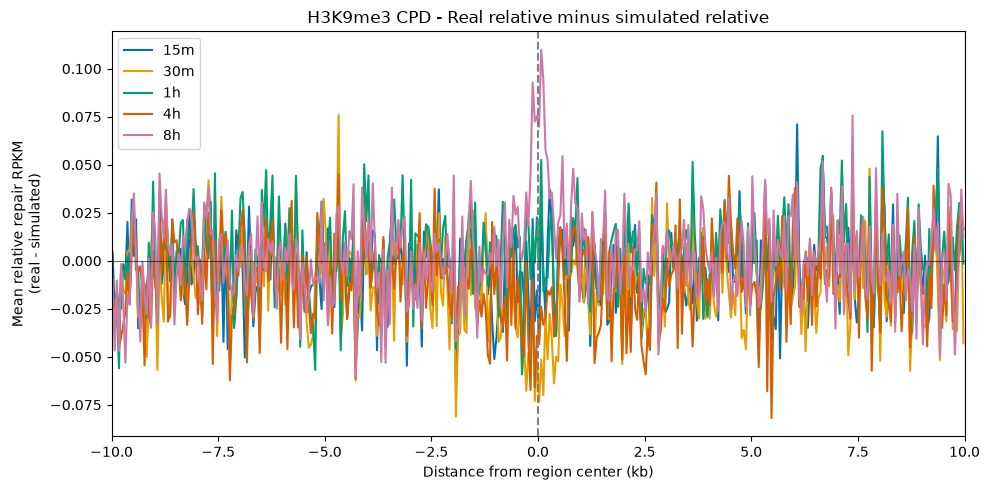

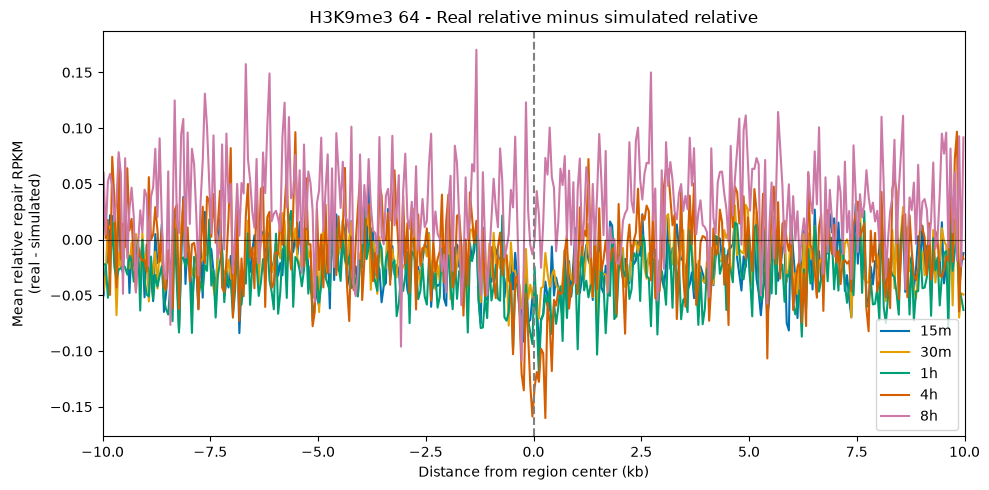

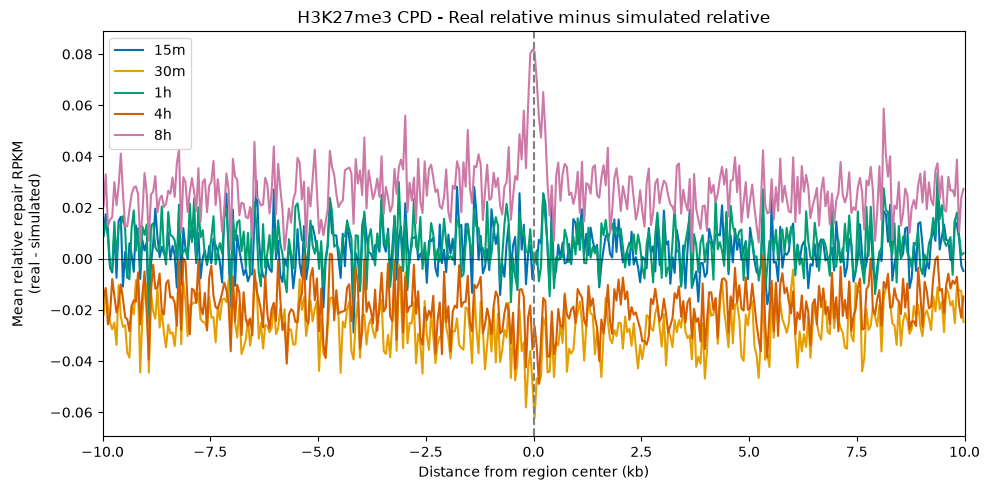

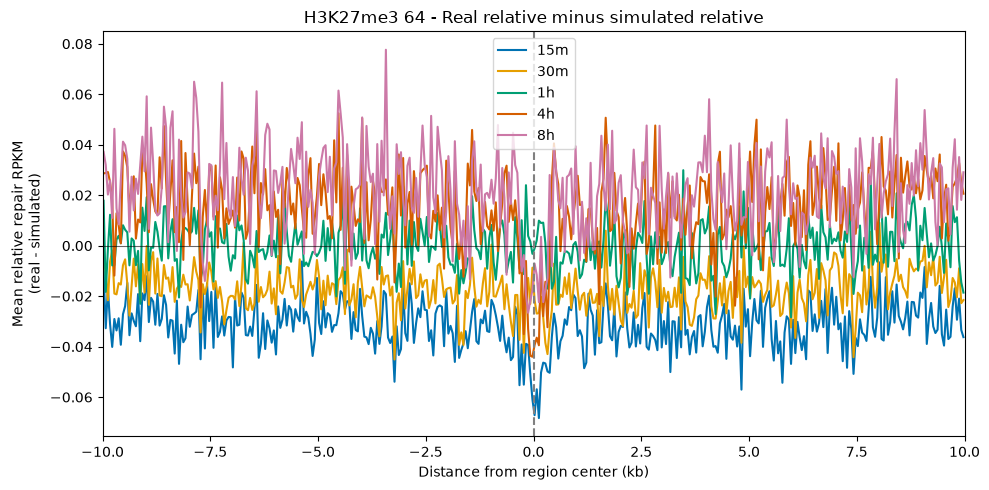

In [ ]:
REGIONS = ['ATAC', 'H3K9me3', 'H3K27me3']
DAMAGES = ['CPD', '64']
TIMES = ['15m', '30m', '1h', '4h', '8h']
COLORS = {
    '15m': '#0072B2',
    '30m': '#E69F00',
    '1h': '#009E73',
    '4h': '#D55E00'
    '8h': '#CC79A7',
}

for region in REGIONS:
    for damage in DAMAGES:
        fig, ax = plt.subplots(figsize=(10, 5))

        for time in TIMES:
            data = summary[
                (summary['region'] == region)
                & (summary['damage'] == damage)
                & (summary['time'] == time)
            ]
            distance_kb = (data['window'] - 200.5) * 0.05
            ax.plot(
                distance_kb,
                data['relative_real_minus_sim'],
                label=time,
                color=COLORS[time],
            )

        # The horizontal zero line marks equal real and simulated relative repair.
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
        # The dashed vertical line marks the region center.
        ax.axvline(0, color='gray', linestyle='--')
        ax.set_xlim(-10, 10)
        ax.set_xlabel('Distance from region center (kb)')
        ax.set_ylabel('Mean relative repair RPKM\n(real - simulated)')
        ax.set_title(f'{region} {damage} - Real relative minus simulated relative')
        ax.legend()
        fig.tight_layout()
        fig.savefig(
            OUTPUT_DIR / f'{region}_{damage}_relative_real_minus_sim.png',
            dpi=300,
        )
        plt.show()